In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

In [2]:
data=pd.read_csv("/content/LoanApprovalPrediction.csv")

In [3]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


In [5]:
data.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,586.000000,598.000000,598.000000,577.000000,584.000000,549.000000
mean,0.755973,5292.252508,1631.499866,144.968804,341.917808,0.843352
std,1.007751,5807.265364,2953.315785,82.704182,65.205994,0.363800
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.000000,360.000000,1.000000
50%,0.000000,3806.000000,1211.500000,127.000000,360.000000,1.000000
75%,1.750000,5746.000000,2324.000000,167.000000,360.000000,1.000000
max,3.000000,81000.000000,41667.000000,650.000000,480.000000,1.000000


In [6]:
data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,12
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,21
Loan_Amount_Term,14


In [7]:
data.dropna(inplace=True)

In [8]:
data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [9]:
# Binary mapping
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})
data['Married'] = data['Married'].map({'Yes': 1, 'No': 0})
data['Education'] = data['Education'].map({'Graduate': 1, 'Not Graduate': 0})
data['Self_Employed'] = data['Self_Employed'].map({'Yes': 1, 'No': 0})
data['Loan_Status'] = data['Loan_Status'].map({'Y': 1, 'N': 0})

In [10]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1.0,1,0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,1,1,0.0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,1,1,0.0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,1,0,0.0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,1,1,2.0,1,1,5417,4196.0,267.0,360.0,1.0,Urban,1


In [11]:
from sklearn.preprocessing import OneHotEncoder

In [12]:
ohe = OneHotEncoder(drop='first', sparse_output=False)

encoded = ohe.fit_transform(data[['Property_Area']])
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['Property_Area'])
)

data = pd.concat([data.reset_index(drop=True), encoded_df], axis=1)
data.drop('Property_Area', axis=1, inplace=True)
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,LP001003,1,1,1.0,1,0,4583,1508.0,128.0,360.0,1.0,0,0.0,0.0
1,LP001005,1,1,0.0,1,1,3000,0.0,66.0,360.0,1.0,1,0.0,1.0
2,LP001006,1,1,0.0,0,0,2583,2358.0,120.0,360.0,1.0,1,0.0,1.0
3,LP001008,1,0,0.0,1,0,6000,0.0,141.0,360.0,1.0,1,0.0,1.0
4,LP001011,1,1,2.0,1,1,5417,4196.0,267.0,360.0,1.0,1,0.0,1.0


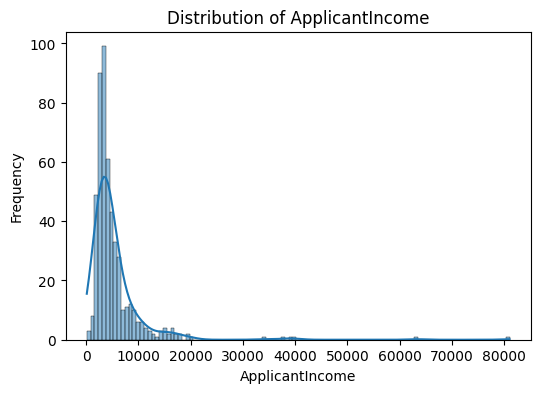

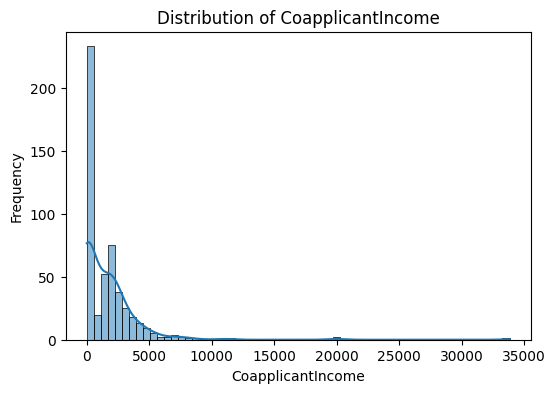

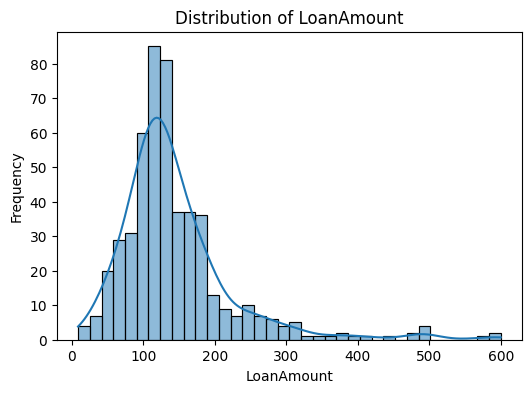

In [13]:
import matplotlib.pyplot as plt


num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

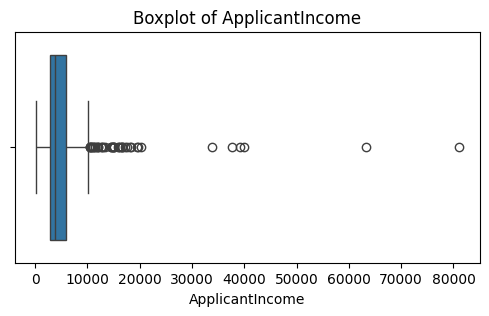

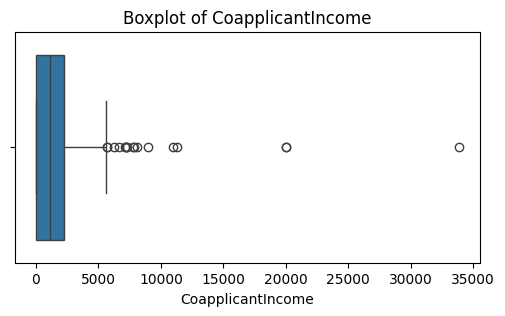

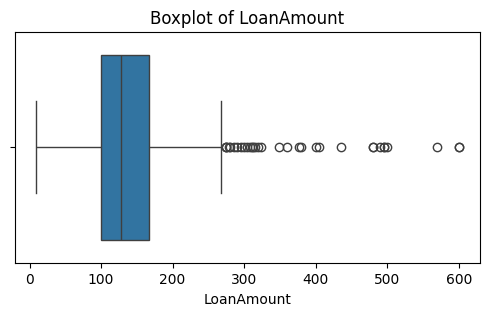

In [14]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


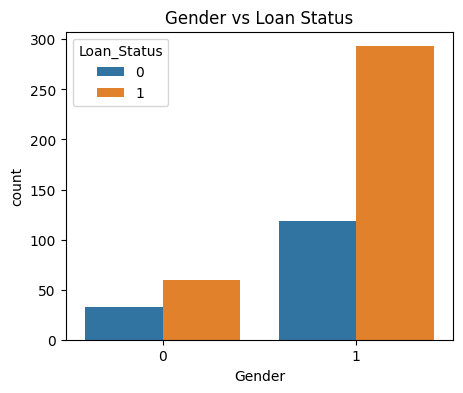

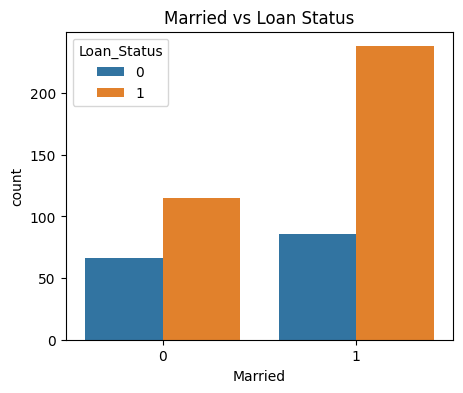

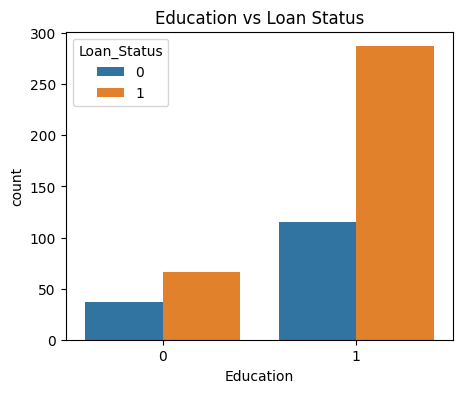

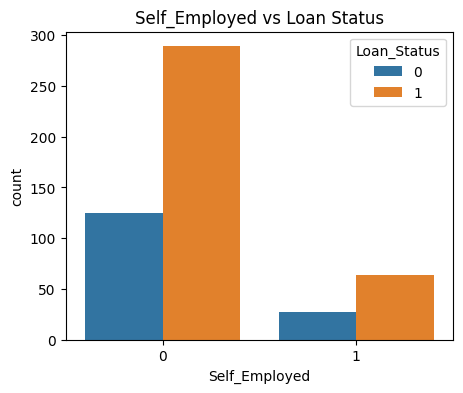

In [15]:
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed']

for col in cat_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(x=col, hue='Loan_Status', data=data)
    plt.title(f"{col} vs Loan Status")
    plt.show()


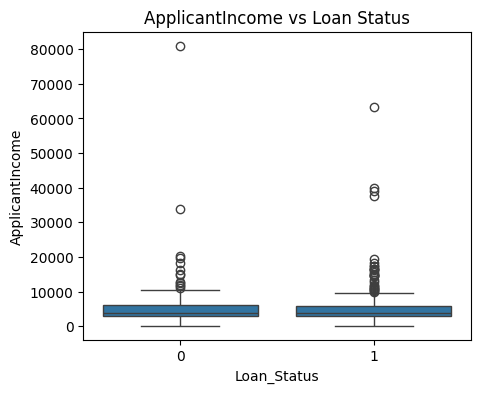

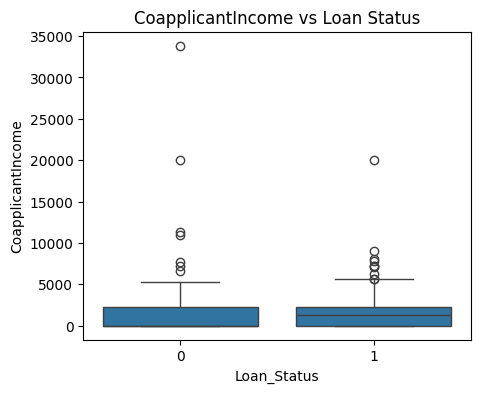

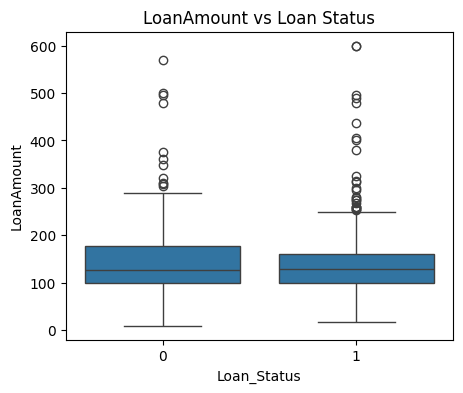

In [16]:
for col in num_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(x='Loan_Status', y=col, data=data)
    plt.title(f"{col} vs Loan Status")
    plt.show()


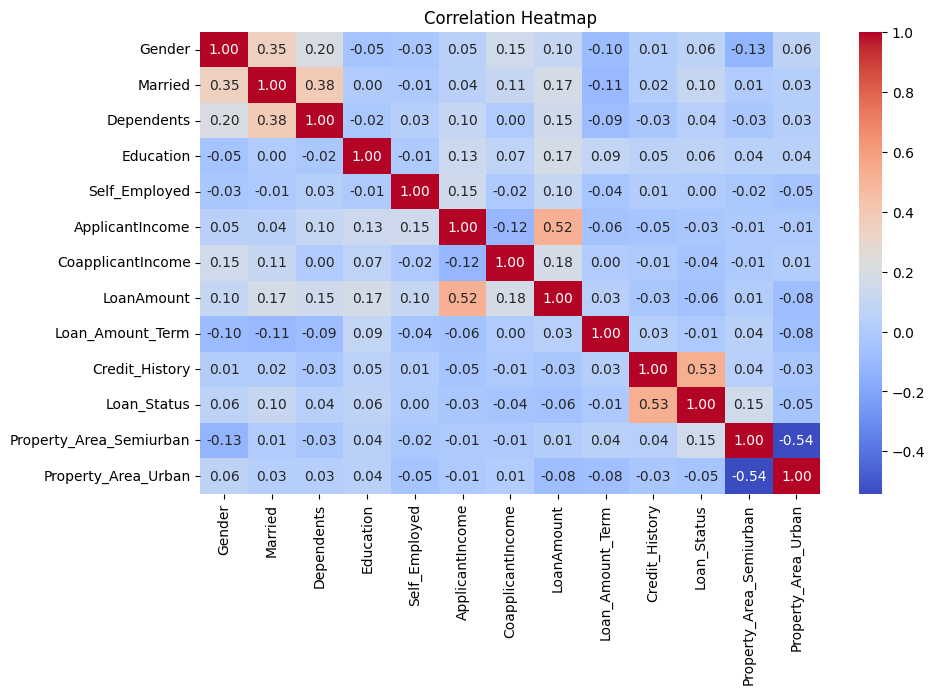

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()


In [18]:
data.groupby('Loan_Status')['LoanAmount'].mean()


,LoanAmount
Loan_Status,
0,151.855263
1,141.427762


In [19]:
data.groupby('Credit_History')['Loan_Status'].mean()
#Applicants with good credit history have a significantly higher approval rate.

,Loan_Status
Credit_History,
0.0,0.098592
1.0,0.797235


In [20]:
import plotly.express as px

fig = px.histogram(
    data,
    x="ApplicantIncome",
    color="Loan_Status",
    barmode="overlay",
    title="Applicant Income vs Loan Status"
)
fig.show()


In [37]:

#  Separate Features and Target

if 'Loan_Status' in data.columns:
    X = data.drop('Loan_Status', axis=1)
    y = data['Loan_Status']

    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
else:
    raise ValueError("❌ 'Loan_Status' column not found in data!")

Features shape: (505, 13)
Target shape: (505,)


#  Train-Test Split


In [22]:


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n✓ Data split complete:")
print(f"  - Training set: {X_train.shape[0]} samples")
print(f"  - Test set: {X_test.shape[0]} samples")


✓ Data split complete:
  - Training set: 404 samples
  - Test set: 101 samples


# Feature Scaling


In [39]:
from sklearn.preprocessing import StandardScaler

num_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term'
]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("✓ Feature scaling complete")

✓ Feature scaling complete


In [40]:

#  Separate Features and Target

X = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']

# Drop Loan_ID
if 'Loan_ID' in X.columns:
    X = X.drop('Loan_ID', axis=1)
    print("✓ Loan_ID column dropped")

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


#  Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n✓ Data split complete")


#  Feature Scaling

from sklearn.preprocessing import StandardScaler

num_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term'
]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("✓ Feature scaling complete")


#  SMOTE

from imblearn.over_sampling import SMOTE
import numpy as np

print("\nHandling Class Imbalance with SMOTE...")
print(f"Original class distribution: {np.bincount(y_train)}")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Balanced class distribution: {np.bincount(y_train_balanced)}")
print("\n✓ SMOTE applied successfully")


✓ Loan_ID column dropped
Features shape: (505, 12)
Target shape: (505,)

✓ Data split complete
✓ Feature scaling complete

Handling Class Imbalance with SMOTE...
Original class distribution: [122 282]
Balanced class distribution: [282 282]

✓ SMOTE applied successfully


#MODEL TRAINING & EVALUATION

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dictionary to store results
results = {}

#  LOGISTIC REGRESSION

In [26]:
print("\n1. Training Logistic Regression...")
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_balanced, y_train_balanced)

y_pred_lr = log_reg.predict(X_test)

results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr),
    'model': log_reg
}

print(f"   Accuracy: {results['Logistic Regression']['accuracy']:.4f}")


1. Training Logistic Regression...
   Accuracy: 0.7228


In [27]:
print("\n2. Training Decision Tree...")
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=20
)
dt.fit(X_train_balanced, y_train_balanced)

y_pred_dt = dt.predict(X_test)

results['Decision Tree'] = {
    'accuracy': accuracy_score(y_test, y_pred_dt),
    'precision': precision_score(y_test, y_pred_dt),
    'recall': recall_score(y_test, y_pred_dt),
    'f1': f1_score(y_test, y_pred_dt),
    'model': dt
}

print(f"   Accuracy: {results['Decision Tree']['accuracy']:.4f}")



2. Training Decision Tree...
   Accuracy: 0.7129


#  RANDOM FOREST

In [28]:
print("\n3. Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=15
)
rf.fit(X_train_balanced, y_train_balanced)

y_pred_rf = rf.predict(X_test)

results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf),
    'model': rf
}

print(f"   Accuracy: {results['Random Forest']['accuracy']:.4f}")



3. Training Random Forest...
   Accuracy: 0.7624


# MODEL COMPARISON



Model Performance Comparison:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.722772   0.811594 0.788732  0.800000
      Decision Tree  0.712871   0.800000 0.788732  0.794326
      Random Forest  0.762376   0.821918 0.845070  0.833333

🏆 Best Model: Random Forest
   Accuracy: 0.7624

✓ Model comparison plot saved as 'model_comparison.png'


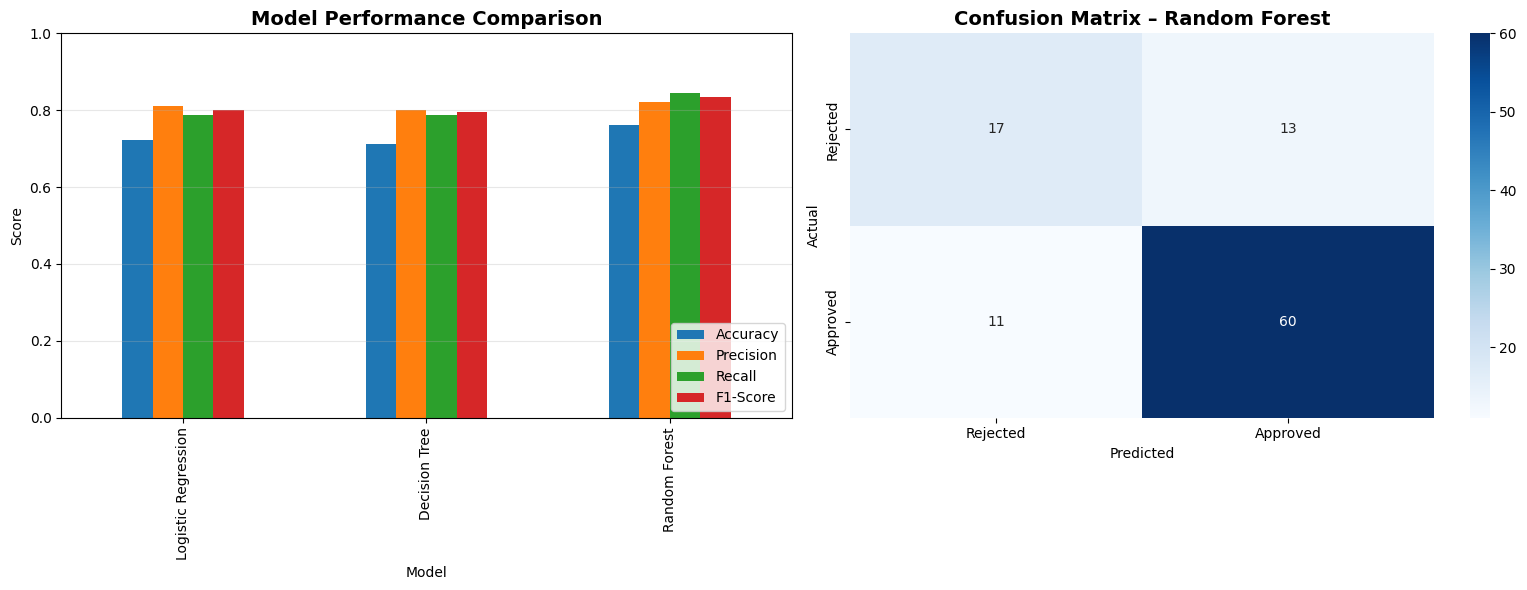

In [36]:
from sklearn.metrics import confusion_matrix


# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-Score': [results[m]['f1'] for m in results]
})

print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# --------------------------------------------------
# Selecting Best Model (Based on Accuracy)
# --------------------------------------------------
best_model_name = comparison_df.loc[
    comparison_df['Accuracy'].idxmax(), 'Model'
]
best_model = results[best_model_name]['model']

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Accuracy: {results[best_model_name]['accuracy']:.4f}")

# --------------------------------------------------
# Visualization
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Plot 1: Metric Comparison ----
comparison_df.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score']
].plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Model')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(loc='lower right')

# ---- Plot 2: Confusion Matrix (Best Model) ----
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1],
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)

axes[1].set_title(f'Confusion Matrix – {best_model_name}', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Model comparison plot saved as 'model_comparison.png'")
plt.show()


In [30]:
import pickle

# -----------------------------------------
# Saving the best model
# -----------------------------------------
with open('best_loan_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("✓ Best model saved as 'best_loan_model.pkl'")

# -----------------------------------------
# Save the scaler
# -----------------------------------------
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✓ Scaler saved as 'scaler.pkl'")

print("\n✓ Model saving completed successfully!")



STEP 11: SAVING THE MODEL
✓ Best model saved as 'best_loan_model.pkl'
✓ Scaler saved as 'scaler.pkl'

✓ Model saving completed successfully!


In [31]:
import pandas as pd
import numpy as np

def predict_loan_approval(input_data):
    """
    Predict loan approval for new applicant data

    Parameters:
    input_data (dict): Applicant details (raw input)

    Returns:
    dict: Prediction result with probability and confidence
    """

    # -----------------------------------------
    # Convert input to DataFrame
    # -----------------------------------------
    input_df = pd.DataFrame([input_data])

    # -----------------------------------------
    #  Binary Encoding (SAME AS TRAINING)
    # -----------------------------------------
    binary_mappings = {
        'Gender': {'Male': 1, 'Female': 0},
        'Married': {'Yes': 1, 'No': 0},
        'Education': {'Graduate': 1, 'Not Graduate': 0},
        'Self_Employed': {'Yes': 1, 'No': 0}
    }

    for col, mapping in binary_mappings.items():
        if col in input_df.columns:
            input_df[col] = input_df[col].map(mapping)

    # -----------------------------------------
    #  One-Hot Encoding: Property_Area
    # -----------------------------------------
    input_df['Property_Area_Urban'] = 0
    input_df['Property_Area_Semiurban'] = 0

    if 'Property_Area' in input_df.columns:
        if input_df.loc[0, 'Property_Area'] == 'Urban':
            input_df['Property_Area_Urban'] = 1
        elif input_df.loc[0, 'Property_Area'] == 'Semiurban':
            input_df['Property_Area_Semiurban'] = 1

        input_df.drop('Property_Area', axis=1, inplace=True)

    # -----------------------------------------
    #  Ensuring All Training Columns Exist
    # -----------------------------------------
    for col in X.columns:
        if col not in input_df.columns:
            input_df[col] = 0

    # Reorder columns
    input_df = input_df[X.columns]

    # -----------------------------------------
    #  Scaling Numerical Features
    # -----------------------------------------
    num_cols = [
        'ApplicantIncome',
        'CoapplicantIncome',
        'LoanAmount',
        'Loan_Amount_Term'
    ]

    input_df[num_cols] = scaler.transform(input_df[num_cols])

    # -----------------------------------------
    #  Making Prediction
    # -----------------------------------------
    prediction = best_model.predict(input_df)[0]
    probability = best_model.predict_proba(input_df)[0][1]

    return {
        'approved': bool(prediction),
        'approval_probability': round(probability, 4),
        'confidence': (
            'High' if probability >= 0.75
            else 'Medium' if probability >= 0.60
            else 'Low'
        )
    }



STEP 12: CREATING PREDICTION FUNCTION


In [32]:
print("\nExample Prediction:")

sample_input = {
    'Gender': 'Male',
    'Married': 'Yes',
    'Education': 'Graduate',
    'Self_Employed': 'No',
    'ApplicantIncome': 5000,
    'CoapplicantIncome': 1500,
    'LoanAmount': 150,
    'Loan_Amount_Term': 360,
    'Credit_History': 1.0,
    'Property_Area': 'Urban'
}

result = predict_loan_approval(sample_input)

print(f"Loan Approved: {result['approved']}")
print(f"Approval Probability: {result['approval_probability']:.2%}")
print(f"Confidence: {result['confidence']}")



Example Prediction:
Loan Approved: True
Approval Probability: 70.01%
Confidence: Medium


In [35]:
report = f"""
{'='*70}
LOAN APPROVAL PREDICTION - PROJECT REPORT
{'='*70}

1. DATASET INFORMATION
   - Total Records: {data.shape[0]}
   - Total Features (after encoding): {data.shape[1]}
   - Target Variable: Loan_Status (0 = Rejected, 1 = Approved)

2. DATA PREPROCESSING
   - Missing values handled: ✓
   - Categorical encoding applied:
       • Binary encoding for Gender, Married, Education, Self_Employed
       • One-Hot Encoding for Property_Area
   - Feature scaling applied (numerical features only): ✓
   - Class imbalance handled using SMOTE: ✓
   - Identifier columns (Loan_ID) removed: ✓

3. EXPLORATORY DATA ANALYSIS (EDA)
   - Distribution analysis using histograms and boxplots
   - Relationship analysis using bar plots and boxplots
   - Correlation analysis using heatmap
   - Credit_History identified as the strongest predictor

4. MODELS TRAINED
{comparison_df.to_string(index=False)}

5. BEST MODEL
   - Model Name: {best_model_name}
   - Accuracy: {results[best_model_name]['accuracy']:.4f}
   - Precision: {results[best_model_name]['precision']:.4f}
   - Recall: {results[best_model_name]['recall']:.4f}
   - F1-Score: {results[best_model_name]['f1']:.4f}

6. KEY INSIGHTS
   - Credit History is the most influential factor for loan approval
   - Applicants with good credit history have a much higher approval rate
   - Income and loan amount show moderate relationship
   - Property area has an impact on approval probability
   - Binary demographic features alone are weak predictors

7. BUSINESS RECOMMENDATIONS
   - Use the model for automated initial loan screening
   - Prioritize manual review for borderline probability cases (50–65%)
   - Give higher weight to credit history during evaluation
   - Retrain the model periodically with updated data

8. FILES GENERATED
   - best_loan_model.pkl → Trained machine learning model
   - scaler.pkl → Feature scaler for numerical variables
   - model_comparison.png → Model performance comparison
   - feature_importance.png → Feature importance visualization
   - project_report.txt → Complete project report

{'='*70}
PROJECT COMPLETED SUCCESSFULLY!
{'='*70}
"""

print(report)

# Save report
with open('project_report.txt', 'w') as f:
    f.write(report)

print("\n✓ Project report saved as 'project_report.txt'")



LOAN APPROVAL PREDICTION - PROJECT REPORT

1. DATASET INFORMATION
   - Total Records: 505
   - Total Features (after encoding): 14
   - Target Variable: Loan_Status (0 = Rejected, 1 = Approved)

2. DATA PREPROCESSING
   - Missing values handled: ✓
   - Categorical encoding applied:
       • Binary encoding for Gender, Married, Education, Self_Employed
       • One-Hot Encoding for Property_Area
   - Feature scaling applied (numerical features only): ✓
   - Class imbalance handled using SMOTE: ✓
   - Identifier columns (Loan_ID) removed: ✓

3. EXPLORATORY DATA ANALYSIS (EDA)
   - Distribution analysis using histograms and boxplots
   - Relationship analysis using bar plots and boxplots
   - Correlation analysis using heatmap
   - Credit_History identified as the strongest predictor

4. MODELS TRAINED
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.722772   0.811594 0.788732  0.800000
      Decision Tree  0.712871   0.800000 0.788732  0.794326
      Ra